# Hyperparameter Tuning and Tuned Model Evaluation

This notebook tunes Logistic Regression, Random Forest, and XGBoost using the same respondent-level train-test split and preprocessing artifacts created earlier.

The search is performed only on the training data using respondent-grouped cross-validation. The untouched test set is used only after tuning.

The primary tuning metric is **average precision (PR-AUC)** because Cesarean deliveries are the minority class.

## 1. Import Libraries

In [1]:
from pathlib import Path
from time import perf_counter
from scipy.stats import loguniform, randint, uniform

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedGroupKFold
)
from xgboost import XGBClassifier

## 2. Configure the Search

`FAST_MODE = True` runs a smaller search first. Set it to `False` later for a broader final search.

In [2]:
FAST_MODE = True
RANDOM_STATE = 42
CV_FOLDS = 3
PRIMARY_SCORING = "average_precision"

RF_ITERATIONS = 10 if FAST_MODE else 25
XGB_ITERATIONS = 12 if FAST_MODE else 35

print("Fast mode:", FAST_MODE)
print("CV folds:", CV_FOLDS)
print("Primary metric:", PRIMARY_SCORING)
print("Random Forest iterations:", RF_ITERATIONS)
print("XGBoost iterations:", XGB_ITERATIONS)

Fast mode: True
CV folds: 3
Primary metric: average_precision
Random Forest iterations: 10
XGBoost iterations: 12


## 3. Load the Dataset and Saved Artifacts

In [3]:
possible_data_paths = [
    Path("../data/processed/df_model_v1.parquet"),
    Path("data/processed/df_model_v1.parquet")
]

data_path = next(
    (path for path in possible_data_paths if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError("df_model_v1.parquet was not found.")

possible_artifact_paths = [
    Path("../artifacts"),
    Path("artifacts")
]

artifact_path = next(
    (path for path in possible_artifact_paths if path.exists()),
    None
)

if artifact_path is None:
    raise FileNotFoundError(
        "The artifacts folder was not found."
    )

df_model = pd.read_parquet(data_path)

linear_preprocessor = joblib.load(
    artifact_path / "linear_preprocessor.joblib"
)

tree_preprocessor = joblib.load(
    artifact_path / "tree_preprocessor.joblib"
)

split_indices = pd.read_csv(
    artifact_path / "train_test_split_indices.csv"
)

baseline_results_path = (
    artifact_path
    / "baseline_models"
    / "baseline_model_results.csv"
)

baseline_results = (
    pd.read_csv(baseline_results_path, index_col=0)
    if baseline_results_path.exists()
    else None
)

print("Dataset shape:", df_model.shape)
print("Artifact folder:", artifact_path.resolve())

Dataset shape: (201311, 49)
Artifact folder: C:\IPD\IPD\artifacts


## 4. Reconstruct Predictors, Target, and Respondent Groups

In [4]:
candidate_excluded_columns = [
    "respondent_id",
    "birth_index",
    "cluster_number",
    "household_number",
    "respondent_line_number",
    "sample_weight",
    "primary_sampling_unit",
    "sample_stratum_v022",
    "sample_stratum_v023",
    "state",
    "district",
    "delivery_place_code",
    "survey_weight",
    "csection"
]

excluded_columns = [
    column
    for column in candidate_excluded_columns
    if column in df_model.columns
]

X = df_model.drop(columns=excluded_columns).copy()

y = pd.to_numeric(
    df_model["csection"],
    errors="raise"
).astype(int)

groups = df_model["respondent_id"].copy()

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("Unique respondents:", groups.nunique())

Predictor shape: (201311, 36)
Target shape: (201311,)
Unique respondents: 158429


## 5. Define Feature Groups and Convert Data Types

In [5]:
numeric_features = [
    "maternal_age",
    "education_years",
    "wealth_index",
    "birth_order",
    "total_children_ever_born",
    "preceding_birth_interval",
    "age_at_first_birth",
    "bmi",
    "first_anc_timing",
    "anc_visits"
]

categorical_features = [
    "facility_type",
    "residence",
    "religion",
    "social_group",
    "twin_order"
]

binary_features = [
    "health_insurance",
    "anc_doctor",
    "anc_nurse_midwife",
    "anc_traditional_attendant",
    "anc_community_worker",
    "anc_anganwadi_worker",
    "anc_asha_worker",
    "anc_other_provider",
    "no_anc_provider",
    "weight_measured_during_pregnancy",
    "bp_measured_during_pregnancy",
    "urine_sample_during_pregnancy",
    "blood_sample_during_pregnancy",
    "told_about_pregnancy_complications",
    "counselled_vaginal_bleeding",
    "counselled_convulsions",
    "counselled_prolonged_labour",
    "counselled_severe_abdominal_pain",
    "counselled_high_blood_pressure",
    "convulsions_during_pregnancy",
    "swelling_during_pregnancy"
]


def create_sklearn_compatible_frame(data):
    converted = pd.DataFrame(index=data.index)

    for feature in numeric_features:
        converted[feature] = (
            pd.to_numeric(
                data[feature],
                errors="coerce"
            )
            .to_numpy(
                dtype=np.float64,
                na_value=np.nan
            )
        )

    for feature in categorical_features + binary_features:
        converted[feature] = (
            data[feature]
            .astype("string")
            .fillna("Missing")
            .to_numpy(dtype=str)
        )

    return converted[data.columns]


X = create_sklearn_compatible_frame(X)

display(X.dtypes.value_counts())

str        26
float64    10
Name: count, dtype: int64

## 6. Recreate the Saved Train-Test Split

In [6]:
if len(split_indices) != len(df_model):
    raise ValueError(
        "Saved split length does not match the dataset."
    )

split_indices = split_indices.sort_values(
    "row_index"
).reset_index(drop=True)

if not np.array_equal(
    split_indices["row_index"].to_numpy(),
    df_model.index.to_numpy()
):
    raise ValueError(
        "Saved row indices do not match the dataset."
    )

train_mask = split_indices["split"].eq("train").to_numpy()
test_mask = split_indices["split"].eq("test").to_numpy()

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

groups_train = groups.loc[train_mask].copy()
groups_test = groups.loc[test_mask].copy()

overlap = set(groups_train).intersection(
    set(groups_test)
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Respondent overlap:", len(overlap))

if overlap:
    raise ValueError("Respondent leakage detected.")

Training shape: (161048, 36)
Test shape: (40263, 36)
Respondent overlap: 0


## 7. Apply the Saved Preprocessors

In [7]:
X_train_linear = linear_preprocessor.transform(X_train)
X_test_linear = linear_preprocessor.transform(X_test)

X_train_tree = tree_preprocessor.transform(X_train)
X_test_tree = tree_preprocessor.transform(X_test)

print("Linear training shape:", X_train_linear.shape)
print("Linear test shape:", X_test_linear.shape)
print("Tree training shape:", X_train_tree.shape)
print("Tree test shape:", X_test_tree.shape)

Linear training shape: (161048, 99)
Linear test shape: (40263, 99)
Tree training shape: (161048, 99)
Tree test shape: (40263, 99)


## 8. Define Respondent-Grouped Cross-Validation

All records from one respondent remain in the same fold.

In [8]:
grouped_cv = StratifiedGroupKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(grouped_cv)

StratifiedGroupKFold(n_splits=3, random_state=42, shuffle=True)


## 9. Tune Logistic Regression

In [9]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=RANDOM_STATE
)

logistic_parameter_grid = [
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    {
        "solver": ["saga"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10]
    }
]

logistic_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=logistic_parameter_grid,
    scoring=PRIMARY_SCORING,
    cv=grouped_cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

start_time = perf_counter()

logistic_search.fit(
    X_train_linear,
    y_train,
    groups=groups_train
)

logistic_tuning_time = perf_counter() - start_time

print("Best parameters:")
print(logistic_search.best_params_)
print("Best CV PR-AUC:", round(logistic_search.best_score_, 4))
print("Tuning time:", round(logistic_tuning_time, 2), "seconds")

Fitting 3 folds for each of 22 candidates, totalling 66 fits


c:\IPD\IPD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\IPD\IPD\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters:
{'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV PR-AUC: 0.5085
Tuning time: 642.43 seconds


## 10. Tune Random Forest

In [10]:
random_forest_model = RandomForestClassifier(
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=1
)

random_forest_parameter_distributions = {
    "n_estimators": randint(150, 501),
    "max_depth": [None, 8, 12, 16, 20, 30],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True]
}

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=random_forest_parameter_distributions,
    n_iter=RF_ITERATIONS,
    scoring=PRIMARY_SCORING,
    cv=grouped_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

start_time = perf_counter()

random_forest_search.fit(
    X_train_tree,
    y_train,
    groups=groups_train
)

random_forest_tuning_time = perf_counter() - start_time

print("Best parameters:")
print(random_forest_search.best_params_)
print("Best CV PR-AUC:", round(random_forest_search.best_score_, 4))
print("Tuning time:", round(random_forest_tuning_time, 2), "seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'bootstrap': True, 'max_depth': 12, 'max_features': 0.3, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 301}
Best CV PR-AUC: 0.5204
Tuning time: 457.05 seconds


## 11. Tune XGBoost

In [11]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("scale_pos_weight:", round(scale_pos_weight, 3))

xgboost_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist"
)

xgboost_parameter_distributions = {
    "n_estimators": randint(150, 501),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(3, 9),
    "min_child_weight": randint(1, 11),
    "subsample": uniform(0.65, 0.35),
    "colsample_bytree": uniform(0.65, 0.35),
    "gamma": uniform(0.0, 2.0),
    "reg_alpha": loguniform(1e-4, 1.0),
    "reg_lambda": loguniform(0.1, 10.0)
}

xgboost_search = RandomizedSearchCV(
    estimator=xgboost_model,
    param_distributions=xgboost_parameter_distributions,
    n_iter=XGB_ITERATIONS,
    scoring=PRIMARY_SCORING,
    cv=grouped_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

start_time = perf_counter()

xgboost_search.fit(
    X_train_tree,
    y_train,
    groups=groups_train
)

xgboost_tuning_time = perf_counter() - start_time

print("Best parameters:")
print(xgboost_search.best_params_)
print("Best CV PR-AUC:", round(xgboost_search.best_score_, 4))
print("Tuning time:", round(xgboost_tuning_time, 2), "seconds")

scale_pos_weight: 3.499
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters:
{'colsample_bytree': np.float64(0.7141915784487018), 'gamma': np.float64(0.6084844859190754), 'learning_rate': np.float64(0.048164145309070844), 'max_depth': 6, 'min_child_weight': 9, 'n_estimators': 198, 'reg_alpha': np.float64(0.012563152773938664), 'reg_lambda': np.float64(0.6305535040199283), 'subsample': np.float64(0.6663329821247654)}
Best CV PR-AUC: 0.5291
Tuning time: 45.26 seconds


## 12. Define the Tuned-Model Evaluation Function

In [12]:
tuned_results = []
tuned_predictions = {}
best_models = {}


def evaluate_tuned_model(
    model_name,
    model,
    X_train_processed,
    X_test_processed,
    best_cv_score,
    tuning_time_seconds
):
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    y_test_probability = model.predict_proba(
        X_test_processed
    )[:, 1]

    results = {
        "model": model_name,
        "train_accuracy": accuracy_score(
            y_train,
            y_train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            y_test_pred
        ),
        "precision": precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_test,
            y_test_probability
        ),
        "pr_auc": average_precision_score(
            y_test,
            y_test_probability
        ),
        "best_cv_pr_auc": best_cv_score,
        "tuning_time_seconds": tuning_time_seconds
    }

    tuned_results.append(results)
    best_models[model_name] = model

    tuned_predictions[model_name] = {
        "predictions": y_test_pred,
        "probabilities": y_test_probability
    }

    display(pd.DataFrame([results]).round(4))

    print(
        classification_report(
            y_test,
            y_test_pred,
            target_names=[
                "Vaginal delivery",
                "Cesarean section"
            ],
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_test_pred,
        display_labels=["Vaginal", "Cesarean"],
        values_format=",d"
    )

    plt.title(f"Tuned {model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

## 13. Evaluate Tuned Logistic Regression

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,pr_auc,best_cv_pr_auc,tuning_time_seconds
0,Logistic Regression,0.7393,0.7384,0.4444,0.7073,0.5459,0.7943,0.5108,0.5085,642.4273


                  precision    recall  f1-score   support

Vaginal delivery       0.90      0.75      0.82     31314
Cesarean section       0.44      0.71      0.55      8949

        accuracy                           0.74     40263
       macro avg       0.67      0.73      0.68     40263
    weighted avg       0.80      0.74      0.76     40263



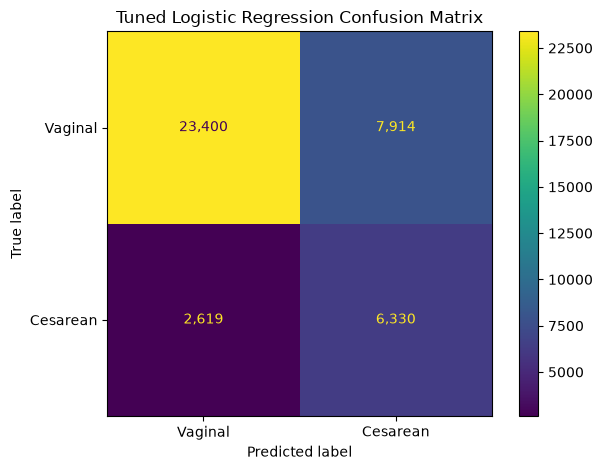

In [13]:
evaluate_tuned_model(
    model_name="Logistic Regression",
    model=logistic_search.best_estimator_,
    X_train_processed=X_train_linear,
    X_test_processed=X_test_linear,
    best_cv_score=logistic_search.best_score_,
    tuning_time_seconds=logistic_tuning_time
)

## 14. Evaluate Tuned Random Forest

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,pr_auc,best_cv_pr_auc,tuning_time_seconds
0,Random Forest,0.765,0.7383,0.4444,0.7101,0.5467,0.8002,0.5262,0.5204,457.0531


                  precision    recall  f1-score   support

Vaginal delivery       0.90      0.75      0.82     31314
Cesarean section       0.44      0.71      0.55      8949

        accuracy                           0.74     40263
       macro avg       0.67      0.73      0.68     40263
    weighted avg       0.80      0.74      0.76     40263



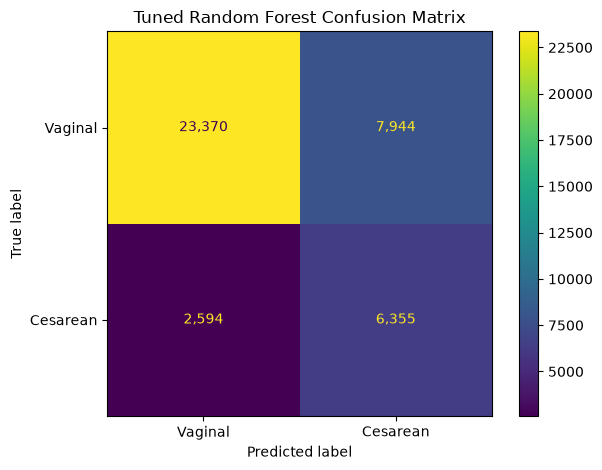

In [14]:
evaluate_tuned_model(
    model_name="Random Forest",
    model=random_forest_search.best_estimator_,
    X_train_processed=X_train_tree,
    X_test_processed=X_test_tree,
    best_cv_score=random_forest_search.best_score_,
    tuning_time_seconds=random_forest_tuning_time
)

## 15. Evaluate Tuned XGBoost

,model,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,pr_auc,best_cv_pr_auc,tuning_time_seconds
0,XGBoost,0.7352,0.7248,0.4313,0.7471,0.5469,0.8033,0.533,0.5291,45.2635


                  precision    recall  f1-score   support

Vaginal delivery       0.91      0.72      0.80     31314
Cesarean section       0.43      0.75      0.55      8949

        accuracy                           0.72     40263
       macro avg       0.67      0.73      0.67     40263
    weighted avg       0.80      0.72      0.75     40263



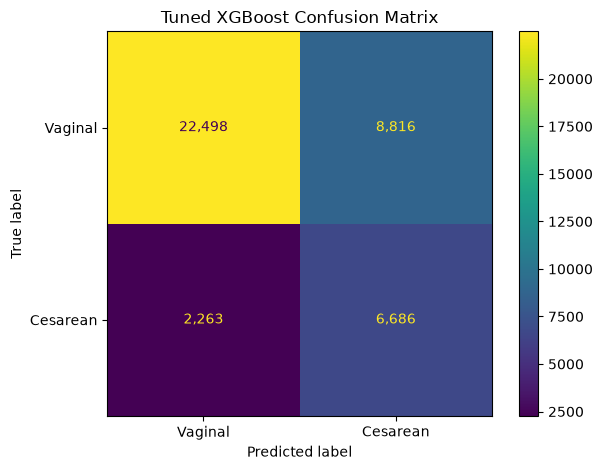

In [15]:
evaluate_tuned_model(
    model_name="XGBoost",
    model=xgboost_search.best_estimator_,
    X_train_processed=X_train_tree,
    X_test_processed=X_test_tree,
    best_cv_score=xgboost_search.best_score_,
    tuning_time_seconds=xgboost_tuning_time
)

## 16. Compare Tuned Models

In [16]:
tuned_results_summary = (
    pd.DataFrame(tuned_results)
    .set_index("model")
    .sort_values(
        ["pr_auc", "roc_auc"],
        ascending=False
    )
)

display(tuned_results_summary.round(4))

,train_accuracy,test_accuracy,precision,recall,f1_score,roc_auc,pr_auc,best_cv_pr_auc,tuning_time_seconds
model,,,,,,,,,
XGBoost,0.7352,0.7248,0.4313,0.7471,0.5469,0.8033,0.5330,0.5291,45.2635
Random Forest,0.7650,0.7383,0.4444,0.7101,0.5467,0.8002,0.5262,0.5204,457.0531
Logistic Regression,0.7393,0.7384,0.4444,0.7073,0.5459,0.7943,0.5108,0.5085,642.4273


## 17. Compare Baseline and Tuned Performance

In [17]:
if baseline_results is not None:
    baseline_comparison = (
        baseline_results[
            [
                "accuracy",
                "precision",
                "recall",
                "f1_score",
                "roc_auc",
                "pr_auc"
            ]
        ]
        .rename(
            columns=lambda column: f"baseline_{column}"
        )
    )

    tuned_for_comparison = (
        tuned_results_summary[
            [
                "test_accuracy",
                "precision",
                "recall",
                "f1_score",
                "roc_auc",
                "pr_auc"
            ]
        ]
        .rename(
            columns={
                "test_accuracy": "tuned_accuracy",
                "precision": "tuned_precision",
                "recall": "tuned_recall",
                "f1_score": "tuned_f1_score",
                "roc_auc": "tuned_roc_auc",
                "pr_auc": "tuned_pr_auc"
            }
        )
    )

    baseline_vs_tuned = baseline_comparison.join(
        tuned_for_comparison,
        how="inner"
    )

    baseline_vs_tuned["roc_auc_change"] = (
        baseline_vs_tuned["tuned_roc_auc"]
        - baseline_vs_tuned["baseline_roc_auc"]
    )

    baseline_vs_tuned["pr_auc_change"] = (
        baseline_vs_tuned["tuned_pr_auc"]
        - baseline_vs_tuned["baseline_pr_auc"]
    )

    baseline_vs_tuned["recall_change"] = (
        baseline_vs_tuned["tuned_recall"]
        - baseline_vs_tuned["baseline_recall"]
    )

    baseline_vs_tuned["f1_change"] = (
        baseline_vs_tuned["tuned_f1_score"]
        - baseline_vs_tuned["baseline_f1_score"]
    )

    display(baseline_vs_tuned.round(4))
else:
    print("Baseline results were not found.")

,baseline_accuracy,baseline_precision,baseline_recall,baseline_f1_score,baseline_roc_auc,baseline_pr_auc,tuned_accuracy,tuned_precision,tuned_recall,tuned_f1_score,tuned_roc_auc,tuned_pr_auc,roc_auc_change,pr_auc_change,recall_change,f1_change
model,,,,,,,,,,,,,,,,
XGBoost,0.7259,0.4325,0.7479,0.5481,0.8035,0.5333,0.7248,0.4313,0.7471,0.5469,0.8033,0.5330,-0.0002,-0.0003,-0.0008,-0.0012
Logistic Regression,0.7383,0.4443,0.7071,0.5457,0.7943,0.5109,0.7384,0.4444,0.7073,0.5459,0.7943,0.5108,0.0000,-0.0000,0.0002,0.0001
Random Forest,0.7964,0.5866,0.2846,0.3833,0.7904,0.5040,0.7383,0.4444,0.7101,0.5467,0.8002,0.5262,0.0098,0.0221,0.4255,0.1634


## 18. Compare ROC Curves

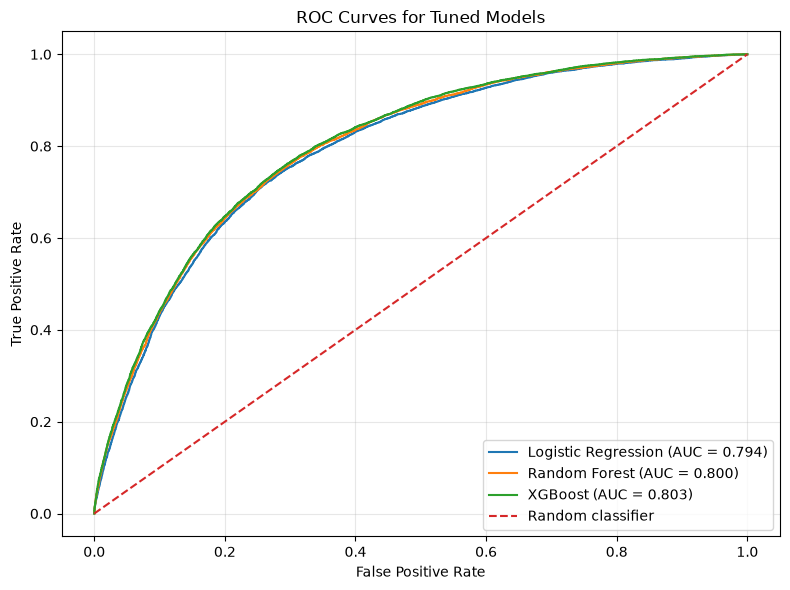

In [18]:
plt.figure(figsize=(8, 6))

for model_name, values in tuned_predictions.items():
    fpr, tpr, _ = roc_curve(
        y_test,
        values["probabilities"]
    )

    auc_value = roc_auc_score(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Tuned Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Compare Precision-Recall Curves

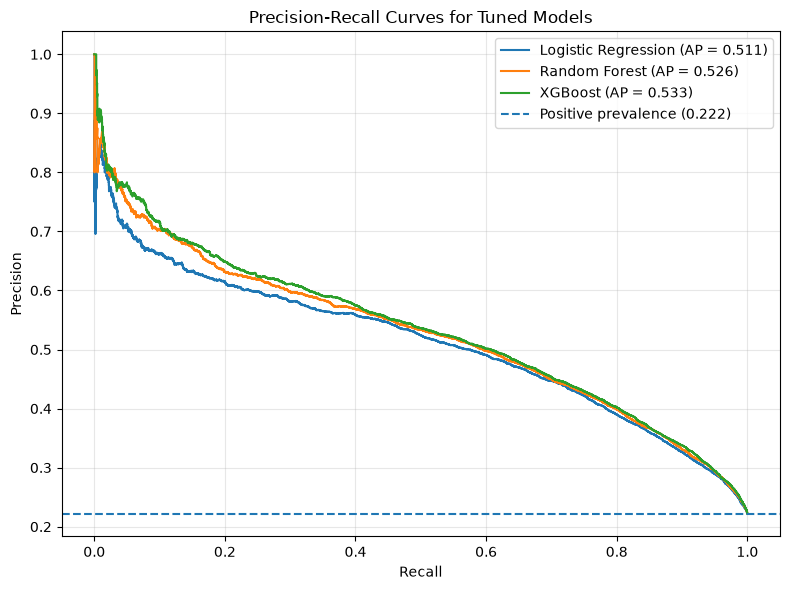

In [19]:
plt.figure(figsize=(8, 6))

for model_name, values in tuned_predictions.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_test,
        values["probabilities"]
    )

    pr_auc_value = average_precision_score(
        y_test,
        values["probabilities"]
    )

    plt.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP = {pr_auc_value:.3f})"
    )

baseline_precision = y_test.mean()

plt.axhline(
    baseline_precision,
    linestyle="--",
    label=f"Positive prevalence ({baseline_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves for Tuned Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Inspect Cross-Validation Overfitting

In [20]:
search_objects = {
    "Logistic Regression": logistic_search,
    "Random Forest": random_forest_search,
    "XGBoost": xgboost_search
}

cv_overfitting_summary = []

for model_name, search in search_objects.items():
    best_index = search.best_index_

    train_score = (
        search.cv_results_["mean_train_score"][best_index]
    )

    validation_score = (
        search.cv_results_["mean_test_score"][best_index]
    )

    cv_overfitting_summary.append({
        "model": model_name,
        "mean_train_pr_auc": train_score,
        "mean_validation_pr_auc": validation_score,
        "train_validation_gap": (
            train_score - validation_score
        )
    })

cv_overfitting_summary = (
    pd.DataFrame(cv_overfitting_summary)
    .set_index("model")
    .sort_values(
        "train_validation_gap",
        ascending=False
    )
)

display(cv_overfitting_summary.round(4))

,mean_train_pr_auc,mean_validation_pr_auc,train_validation_gap
model,,,
Random Forest,0.6266,0.5204,0.1062
XGBoost,0.5739,0.5291,0.0448
Logistic Regression,0.5094,0.5085,0.0009


## 21. Select the Leading Tuned Model

In [21]:
leading_model_name = (
    tuned_results_summary["pr_auc"]
    .idxmax()
)

print("Leading model by test PR-AUC:")
print(leading_model_name)

display(
    tuned_results_summary
    .loc[leading_model_name]
    .to_frame("value")
    .round(4)
)

Leading model by test PR-AUC:
XGBoost


,value
train_accuracy,0.7352
test_accuracy,0.7248
precision,0.4313
recall,0.7471
f1_score,0.5469
roc_auc,0.8033
pr_auc,0.5330
best_cv_pr_auc,0.5291
tuning_time_seconds,45.2635


## 22. Save Tuned Models and Results

In [22]:
tuned_output_path = (
    artifact_path
    / "tuned_models"
)

tuned_output_path.mkdir(
    parents=True,
    exist_ok=True
)

for model_name, model in best_models.items():
    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    joblib.dump(
        model,
        tuned_output_path
        / f"tuned_{safe_name}.joblib"
    )

for model_name, search in search_objects.items():
    safe_name = (
        model_name
        .lower()
        .replace(" ", "_")
    )

    joblib.dump(
        search,
        tuned_output_path
        / f"{safe_name}_search.joblib"
    )

tuned_results_summary.to_csv(
    tuned_output_path
    / "tuned_model_results.csv"
)

cv_overfitting_summary.to_csv(
    tuned_output_path
    / "cv_overfitting_summary.csv"
)

if baseline_results is not None:
    baseline_vs_tuned.to_csv(
        tuned_output_path
        / "baseline_vs_tuned_comparison.csv"
    )

with open(
    tuned_output_path / "leading_model.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(leading_model_name)

print("Saved at:")
print(tuned_output_path.resolve())

Saved at:
C:\IPD\IPD\artifacts\tuned_models


## 23. Hyperparameter-Tuning Summary

## Interpretation

Hyperparameter tuning was performed using respondent-grouped cross-validation with PR-AUC as the primary optimization metric. The tuned models were then evaluated on the held-out test set and compared with their baseline counterparts.

### Best Hyperparameters

**Logistic Regression**
- Solver: `saga`
- Penalty: `L1`
- C: `1`

**Random Forest**
- Number of trees: `301`
- Maximum depth: `12`
- Maximum features per split: `0.3`
- Minimum samples per split: `5`
- Minimum samples per leaf: `8`
- Bootstrap sampling: `True`

**XGBoost**
- Learning rate: `0.048`
- Maximum depth: `6`
- Number of trees: `198`
- Minimum child weight: `9`
- Subsample: `0.666`
- Column sample per tree: `0.714`
- Gamma: `0.608`
- L1 regularization (alpha): `0.0126`
- L2 regularization (lambda): `0.631`
- Scale positive weight: `3.499`

### Cross-Validated Performance

The best cross-validated PR-AUC values were:

| Model | Best CV PR-AUC |
|--------|---------------:|
| XGBoost | **0.5291** |
| Random Forest | **0.5204** |
| Logistic Regression | **0.5085** |

XGBoost achieved the highest cross-validation performance, indicating the strongest ability to distinguish Cesarean deliveries from vaginal deliveries while accounting for class imbalance.

### Effect of Hyperparameter Tuning

Hyperparameter tuning affected the three models differently.

- **Logistic Regression** showed almost no change across all evaluation metrics, indicating that the default configuration was already close to optimal.
- **Random Forest** showed substantial improvement after tuning. Recall increased from **28.46%** to **71.01%**, while ROC-AUC, PR-AUC, and F1-score also improved considerably. Although overall accuracy decreased, the tuned model became much more effective at identifying Cesarean deliveries.
- **XGBoost** showed only negligible differences compared with the baseline model, suggesting that the default XGBoost parameters were already well suited to this dataset.

### Cross-Validation Generalization

The difference between training and validation PR-AUC was examined to assess overfitting.

| Model | Train-Validation Gap |
|--------|---------------------:|
| Logistic Regression | **0.0009** |
| XGBoost | **0.0448** |
| Random Forest | **0.1062** |

Logistic Regression exhibited virtually no overfitting, while XGBoost demonstrated only mild overfitting with strong generalization. Random Forest showed the largest gap but remained acceptable after tuning.

### Final Model Selection

The tuned XGBoost model achieved:

- Highest Recall (**74.71%**)
- Highest F1-score (**0.5469**)
- Highest ROC-AUC (**0.8033**)
- Highest PR-AUC (**0.5330**)
- Strong cross-validation performance (**0.5291**)
- Minimal difference between training and test performance

Although Logistic Regression achieved slightly higher overall accuracy, accuracy was not used as the primary selection criterion because Cesarean delivery represents the minority class. Greater emphasis was placed on Recall, PR-AUC, ROC-AUC, and F1-score.

Based on these results, the **tuned XGBoost model** was selected as the final predictive model. This model will be used in the subsequent stages of the project, including probability calibration (if required), threshold optimization, and SHAP-based explainability analysis.